<a href="https://colab.research.google.com/github/joyngeno21-ui/Joy-AI-Assignment/blob/main/Notebooks/Chap08/8_1_MNIST_1D_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 8.1: MNIST_1D_Performance**

This notebook runs a simple neural network on the MNIST1D dataset as in figure 8.2a. It uses code from https://github.com/greydanus/mnist1d to generate the data.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.

In [1]:
# Run this if you're in a Colab to install MNIST 1D repository
%pip install git+https://github.com/greydanus/mnist1d

  Cloning https://github.com/greydanus/mnist1d to /tmp/pip-req-build-cqb9h81s
  Running command git clone --filter=blob:none --quiet https://github.com/greydanus/mnist1d /tmp/pip-req-build-cqb9h81s
  Resolved https://github.com/greydanus/mnist1d to commit 7878d96082abd200c546a07a4101fa90b30fdf7e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mnist1d: filename=mnist1d-0.0.2.post16-py3-none-any.whl size=14665 sha256=1d82d529fd32ec0dd598f37b207823b96c2de35379a1262b9497ead5ce0c8f1c
  Stored in directory: /tmp/pip-ephem-wheel-cache-239cmk8j/wheels/18/40/b6/29381fee9b4c80fdbc304d52bb065a7286bbcca5ca2b8737c0
Successfully built mnist1d


In [2]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
import mnist1d

Let's generate a training and test dataset using the MNIST1D code.  The dataset gets saved as a .pkl file so it doesn't have to be regenerated each time.

In [3]:
args = mnist1d.data.get_dataset_args()
data = mnist1d.data.get_dataset(args, path='./mnist1d_data.pkl', download=False, regenerate=False)

# The training and test input and outputs are in
# data['x'], data['y'], data['x_test'], and data['y_test']
print("Examples in training set: {}".format(len(data['y'])))
print("Examples in test set: {}".format(len(data['y_test'])))
print("Length of each example: {}".format(data['x'].shape[-1]))

Did or could not load data from ./mnist1d_data.pkl. Rebuilding dataset...
Examples in training set: 4000
Examples in test set: 1000
Length of each example: 40


### Hyperparameter Configuration

Adjust the values in the cell below to experiment with different model configurations and training settings.

In [7]:
# Model Architecture Parameters
D_i = data['x'].shape[-1]    # Input dimensions (derived from data)
D_o = len(np.unique(data['y'])) # Output dimensions (derived from data)
D_k = 100                   # Hidden dimensions (can be changed)

# Training Parameters
learning_rate = 0.05
momentum = 0.9
batch_size = 100
n_epoch = 50

In [8]:
D_i = D_i    # Input dimensions (now from config cell)
D_k = D_k    # Hidden dimensions (now from config cell)
D_o = D_o    # Output dimensions (now from config cell)
# TODO:
# Define a model with two hidden layers of size 100
# And ReLU activations between them
# Replace this line (see Figure 7.8 of book for help):
model = nn.Sequential(
    nn.Linear(D_i, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_k),
    nn.ReLU(),
    nn.Linear(D_k, D_o)
)

def weights_init(layer_in):
  # TODO:
  # Initialize the parameters with He initialization
  # Replace this line (see figure 7.8 of book for help)
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight, nonlinearity='relu')
    if layer_in.bias is not None:
      nn.init.constant_(layer_in.bias, 0)


# Call the function you just defined
model.apply(weights_init)


Sequential(
  (0): Linear(in_features=40, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=100, bias=True)
  (3): ReLU()
  (4): Linear(in_features=100, out_features=10, bias=True)
)

In [9]:
# choose cross entropy loss function (equation 5.24)
loss_function = torch.nn.CrossEntropyLoss()
# construct SGD optimizer and initialize learning rate and momentum
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate, momentum=momentum)
# object that decreases learning rate by half every 10 epochs
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)
x_train = torch.tensor(data['x'].astype('float32'))
y_train = torch.tensor(data['y'].transpose().astype('int64'))
x_test= torch.tensor(data['x_test'].astype('float32'))
y_test = torch.tensor(data['y_test'].astype('int64'))

# load the data into a class that creates the batches
data_loader = DataLoader(TensorDataset(x_train,y_train), batch_size=batch_size, shuffle=True, worker_init_fn=np.random.seed(1))

# Initialize model weights
model.apply(weights_init)

# loop over the dataset n_epoch times
# store the loss and the % correct at each epoch
losses_train = np.zeros((n_epoch))
errors_train = np.zeros((n_epoch))
losses_test = np.zeros((n_epoch))
errors_test = np.zeros((n_epoch))

for epoch in range(n_epoch):
  # loop over batches
  for i, batch in enumerate(data_loader):
    # retrieve inputs and labels for this batch
    x_batch, y_batch = batch
    # zero the parameter gradients
    optimizer.zero_grad()
    # forward pass -- calculate model output
    pred = model(x_batch)
    # compute the loss
    loss = loss_function(pred, y_batch)
    # backward pass
    loss.backward()
    # SGD update
    optimizer.step()

  # Run whole dataset to get statistics -- normally wouldn't do this
  pred_train = model(x_train)
  pred_test = model(x_test)
  _, predicted_train_class = torch.max(pred_train.data, 1);
  _, predicted_test_class = torch.max(pred_test.data, 1);
  errors_train[epoch] = 100 - 100 * (predicted_train_class == y_train).float().sum() / len(y_train)
  errors_test[epoch]= 100 - 100 * (predicted_test_class == y_test).float().sum() / len(y_test)
  losses_train[epoch] = loss_function(pred_train, y_train).item()
  losses_test[epoch]= loss_function(pred_test, y_test).item()
  print(f'Epoch {epoch:5d}, train loss {losses_train[epoch]:.6f}, train error {errors_train[epoch]:3.2f},  test loss {losses_test[epoch]:.6f}, test error {errors_test[epoch]:3.2f}')

  # tell scheduler to consider updating learning rate
  scheduler.step()


Epoch     0, train loss 1.577281, train error 61.30,  test loss 1.636824, test error 66.30
Epoch     1, train loss 1.350888, train error 50.38,  test loss 1.460314, test error 58.80
Epoch     2, train loss 1.200872, train error 46.47,  test loss 1.367809, test error 53.50
Epoch     3, train loss 1.016592, train error 37.25,  test loss 1.255588, test error 48.40
Epoch     4, train loss 0.927730, train error 33.78,  test loss 1.223848, test error 47.10
Epoch     5, train loss 0.786532, train error 27.78,  test loss 1.127065, test error 44.30
Epoch     6, train loss 0.741845, train error 26.60,  test loss 1.137050, test error 43.40
Epoch     7, train loss 0.649062, train error 21.55,  test loss 1.094597, test error 41.90
Epoch     8, train loss 0.608315, train error 21.15,  test loss 1.087565, test error 40.40
Epoch     9, train loss 0.529324, train error 18.35,  test loss 1.099446, test error 39.60
Epoch    10, train loss 0.412153, train error 11.03,  test loss 1.009198, test error 36.80

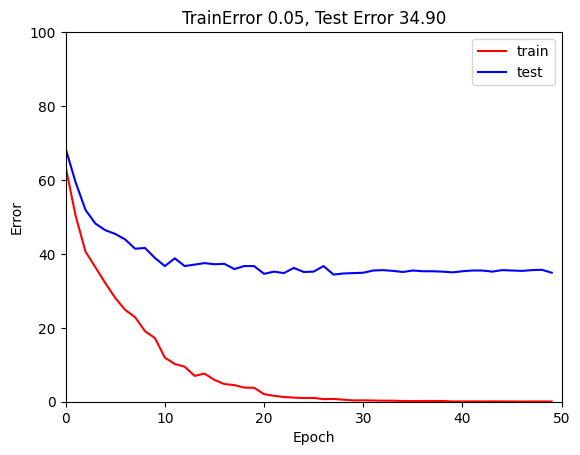

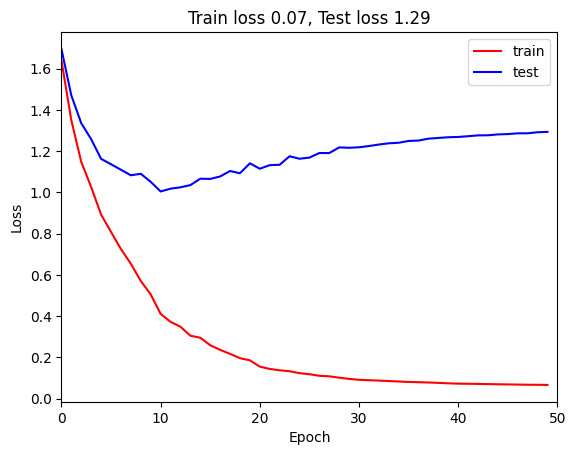

In [6]:
# Plot the results
fig, ax = plt.subplots()
ax.plot(errors_train,'r-',label='train')
ax.plot(errors_test,'b-',label='test')
ax.set_ylim(0,100); ax.set_xlim(0,n_epoch)
ax.set_xlabel('Epoch'); ax.set_ylabel('Error')
ax.set_title('TrainError %3.2f, Test Error %3.2f'%(errors_train[-1],errors_test[-1]))
ax.legend()
plt.show()

# Plot the results
fig, ax = plt.subplots()
ax.plot(losses_train,'r-',label='train')
ax.plot(losses_test,'b-',label='test')
ax.set_xlim(0,n_epoch)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Train loss %3.2f, Test loss %3.2f'%(losses_train[-1],losses_test[-1]))
ax.legend()
plt.show()

**TODO**

Play with the model -- try changing the number of layers, hidden units, learning rate, batch size, momentum or anything else you like.  See if you can improve the test results.
-Manually changing hyperparameters and observing the results like  modifying the model architecture can be a good starting point to gain intuition about the model's behavior and the impact of different parameters. It's often part of the initial exploration phase.
However, for systematic and efficient optimization, it's generally not the best long-term strategy. Manual tuning is time-consuming, prone to human bias, and can easily miss optimal combinations of hyperparameters. More advanced techniques like Grid Search, Random Search, or Bayesian Optimization are often preferred for finding better hyperparameters in a more systematic way.

Is it a good idea to optimize the hyperparameters in this way?  Will the final result be a good estimate of the true test performance?
-If you repeatedly adjust hyperparameters based on the performance observed on the test set, you risk overfitting to the test set. The test set is meant to provide an unbiased estimate of the model's performance on unseen data. If you use it to guide your hyperparameter choices, it's no longer truly 'unseen' data for the hyperparameter selection process.
This can lead to an overly optimistic estimate of your model's true generalization ability. The model might perform well on this specific test set, but not as well on entirely new data. To get a good estimate of true test performance, you should ideally use a separate validation set for hyperparameter tuning, and keep the test set strictly for a final, one-time evaluation after all hyperparameters have been finalized.

